# Healthcare Operations & Revenue Analytics

**SQL + Python analysis of hospital operations, appointment demand, doctor workload, treatment activity, and billing performance.**

### Objectives
- Measure hospital KPIs
- Analyze appointment demand and no-shows
- Evaluate doctor workload
- Analyze treatment and billing performance
- Compare specialization demand and revenue
- Translate results into business recommendations

> Database credentials are intentionally **not stored in this notebook**.


## 1. Import Libraries

In [ ]:

import os
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Secure MySQL Connection

Set `MYSQL_USER`, `MYSQL_PASSWORD`, `MYSQL_HOST`, `MYSQL_PORT`, and `MYSQL_DATABASE` as local environment variables.

Do **not** put your real password in this notebook.


In [ ]:

MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "healthcare_analysis")

if not MYSQL_PASSWORD:
    raise ValueError("MYSQL_PASSWORD is not set.")

connection_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=int(MYSQL_PORT),
    database=MYSQL_DATABASE
)

engine = create_engine(connection_url)

with engine.connect() as conn:
    print("✅ Database connection successful!")


✅ Database connection successful!


## 3. Inspect Database

In [5]:
pd.read_sql("SHOW TABLES;", engine)


,Tables_in_healthcare_analysis
0,appointments
1,billing
2,doctors
3,patients
4,treatments


## 4. Load Tables

In [6]:
patients_df = pd.read_sql("SELECT * FROM patients;", engine)
doctors_df = pd.read_sql("SELECT * FROM doctors;", engine)
appointments_df = pd.read_sql("SELECT * FROM appointments;", engine)
treatments_df = pd.read_sql("SELECT * FROM treatments;", engine)
billing_df = pd.read_sql("SELECT * FROM billing;", engine)

for name, df in {
    "Patients": patients_df,
    "Doctors": doctors_df,
    "Appointments": appointments_df,
    "Treatments": treatments_df,
    "Billing": billing_df
}.items():
    print(f"{name}: {df.shape}")


Patients: (50, 11)
Doctors: (10, 8)
Appointments: (200, 7)
Treatments: (200, 6)
Billing: (200, 7)


## 5. Data Quality Checks

In [7]:
quality = []
for name, df in {
    "patients": patients_df,
    "doctors": doctors_df,
    "appointments": appointments_df,
    "treatments": treatments_df,
    "billing": billing_df
}.items():
    quality.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })
pd.DataFrame(quality)


,table,rows,columns,missing_cells,duplicate_rows
0,patients,50,11,0,0
1,doctors,10,8,0,0
2,appointments,200,7,0,0
3,treatments,200,6,0,0
4,billing,200,7,0,0


In [8]:
print("Appointment statuses:")
display(appointments_df["status"].value_counts(dropna=False))

print("Invalid billing amounts:")
display(billing_df[billing_df["amount"].isna() | (billing_df["amount"] <= 0)])

print("Invalid treatment costs:")
display(treatments_df[treatments_df["cost"].isna() | (treatments_df["cost"] <= 0)])


Appointment statuses:


status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

Invalid billing amounts:


,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status


Invalid treatment costs:


,treatment_id,appointment_id,treatment_type,description,cost,treatment_date


In [9]:
# Referential integrity checks
checks = []

pairs = [
    ("Appointment -> Patient", appointments_df, "patient_id", patients_df, "patient_id"),
    ("Appointment -> Doctor", appointments_df, "doctor_id", doctors_df, "doctor_id"),
    ("Treatment -> Appointment", treatments_df, "appointment_id", appointments_df, "appointment_id"),
    ("Billing -> Patient", billing_df, "patient_id", patients_df, "patient_id"),
    ("Billing -> Treatment", billing_df, "treatment_id", treatments_df, "treatment_id")
]

for label, left, left_key, right, right_key in pairs:
    valid = left[left_key].isin(right[right_key])
    checks.append({"check": label, "invalid_records": int((~valid).sum())})

pd.DataFrame(checks)


,check,invalid_records
0,Appointment -> Patient,0
1,Appointment -> Doctor,0
2,Treatment -> Appointment,0
3,Billing -> Patient,0
4,Billing -> Treatment,0


## 6. Core KPIs

In [10]:
total_patients = patients_df["patient_id"].nunique()
total_doctors = doctors_df["doctor_id"].nunique()
total_appointments = appointments_df["appointment_id"].nunique()
total_treatments = treatments_df["treatment_id"].nunique()
total_billing = billing_df["amount"].sum()

no_shows = (appointments_df["status"] == "No-show").sum()
completed = (appointments_df["status"] == "Completed").sum()
cancelled = (appointments_df["status"] == "Cancelled").sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Patients","Total Doctors","Total Appointments","Total Treatments",
        "Total Billing","No-Show Appointments","No-Show Rate",
        "Completed Appointments","Completed Rate","Cancelled Appointments","Cancellation Rate"
    ],
    "Value": [
        total_patients,total_doctors,total_appointments,total_treatments,round(total_billing,2),
        no_shows,round(no_shows/total_appointments*100,2),
        completed,round(completed/total_appointments*100,2),
        cancelled,round(cancelled/total_appointments*100,2)
    ]
})
kpis


,KPI,Value
0,Total Patients,50.00
1,Total Doctors,10.00
2,Total Appointments,200.00
3,Total Treatments,200.00
4,Total Billing,"551,249.85"
5,No-Show Appointments,52.00
6,No-Show Rate,26.00
7,Completed Appointments,46.00
8,Completed Rate,23.00
9,Cancelled Appointments,51.00


## 7. Patient Analysis

In [11]:
patient_gender = patients_df["gender"].value_counts().rename_axis("gender").reset_index(name="patient_count")
insurance = patients_df["insurance_provider"].value_counts().rename_axis("insurance_provider").reset_index(name="patient_count")
display(patient_gender)
display(insurance)


,gender,patient_count
0,M,31
1,F,19


,insurance_provider,patient_count
0,MedCare Plus,18
1,WellnessCorp,16
2,PulseSecure,10
3,HealthIndia,6


## 8. Appointment Analysis

In [12]:
appointments_df["appointment_date"] = pd.to_datetime(appointments_df["appointment_date"])

status_summary = appointments_df["status"].value_counts().rename_axis("status").reset_index(name="appointment_count")
status_summary["percentage"] = (status_summary["appointment_count"]/total_appointments*100).round(2)

monthly_appointments = (
    appointments_df.assign(month=appointments_df["appointment_date"].dt.to_period("M").astype(str))
    .groupby("month").size().reset_index(name="appointment_count")
)

appointment_specialization = (
    appointments_df.merge(doctors_df[["doctor_id","specialization"]], on="doctor_id", how="left")
    .groupby("specialization").size().reset_index(name="appointment_count")
    .sort_values("appointment_count", ascending=False)
)

display(status_summary)
display(monthly_appointments)
display(appointment_specialization)


,status,appointment_count,percentage
0,No-show,52,26.00
1,Scheduled,51,25.50
2,Cancelled,51,25.50
3,Completed,46,23.00


,month,appointment_count
0,2023-01,20
1,2023-02,14
2,2023-03,19
3,2023-04,25
4,2023-05,19
5,2023-06,18
6,2023-07,16
7,2023-08,15
8,2023-09,11
9,2023-10,14


,specialization,appointment_count
2,Pediatrics,98
0,Dermatology,70
1,Oncology,32


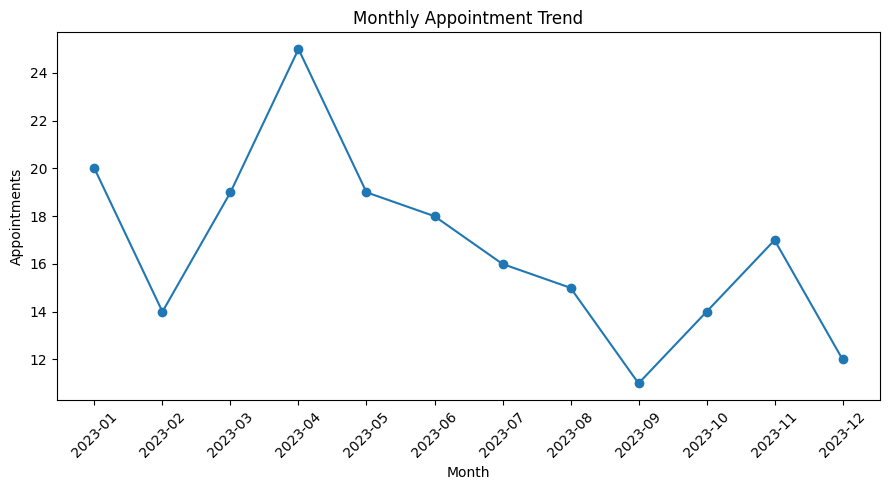

In [13]:
plt.figure(figsize=(9,5))
plt.plot(monthly_appointments["month"], monthly_appointments["appointment_count"], marker="o")
plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. No-Show Analysis

In [14]:
appt_doctor = appointments_df.merge(
    doctors_df[["doctor_id","first_name","last_name","specialization"]],
    on="doctor_id", how="left"
)

no_show_specialization = (
    appt_doctor.groupby("specialization")
    .agg(total_appointments=("appointment_id","count"),
         no_show_appointments=("status", lambda x: (x=="No-show").sum()))
    .reset_index()
)
no_show_specialization["no_show_rate"] = (
    no_show_specialization["no_show_appointments"] /
    no_show_specialization["total_appointments"] * 100
).round(2)

no_show_doctor = (
    appt_doctor.groupby(["doctor_id","first_name","last_name","specialization"])
    .agg(total_appointments=("appointment_id","count"),
         no_show_appointments=("status", lambda x: (x=="No-show").sum()))
    .reset_index()
)
no_show_doctor["no_show_rate"] = (
    no_show_doctor["no_show_appointments"] /
    no_show_doctor["total_appointments"] * 100
).round(2)

display(no_show_specialization.sort_values("no_show_rate", ascending=False))
display(no_show_doctor.sort_values("no_show_rate", ascending=False))


,specialization,total_appointments,no_show_appointments,no_show_rate
0,Dermatology,70,20,28.57
2,Pediatrics,98,25,25.51
1,Oncology,32,7,21.88


,doctor_id,first_name,last_name,specialization,total_appointments,no_show_appointments,no_show_rate
3,D004,David,Jones,Pediatrics,14,5,35.71
8,D009,Sarah,Smith,Pediatrics,17,6,35.29
2,D003,Jane,Smith,Pediatrics,22,7,31.82
4,D005,Sarah,Taylor,Dermatology,29,9,31.03
0,D001,David,Taylor,Dermatology,25,7,28.00
9,D010,Linda,Wilson,Oncology,19,5,26.32
7,D008,Linda,Brown,Dermatology,16,4,25.00
5,D006,Alex,Davis,Pediatrics,24,6,25.00
6,D007,Robert,Davis,Oncology,13,2,15.38
1,D002,Jane,Davis,Pediatrics,21,1,4.76


## 10. Doctor Workload

In [15]:
doctor_workload = (
    appointments_df.groupby("doctor_id")
    .agg(appointment_count=("appointment_id","count"))
    .reset_index()
    .merge(doctors_df[["doctor_id","first_name","last_name","specialization"]],
           on="doctor_id", how="left")
)

doctor_workload["doctor_name"] = doctor_workload["first_name"] + " " + doctor_workload["last_name"]
doctor_workload[["doctor_id","doctor_name","specialization","appointment_count"]].sort_values(
    "appointment_count", ascending=False
)


,doctor_id,doctor_name,specialization,appointment_count
4,D005,Sarah Taylor,Dermatology,29
0,D001,David Taylor,Dermatology,25
5,D006,Alex Davis,Pediatrics,24
2,D003,Jane Smith,Pediatrics,22
1,D002,Jane Davis,Pediatrics,21
9,D010,Linda Wilson,Oncology,19
8,D009,Sarah Smith,Pediatrics,17
7,D008,Linda Brown,Dermatology,16
3,D004,David Jones,Pediatrics,14
6,D007,Robert Davis,Oncology,13


## 11. Treatment Analysis

In [16]:
treatment_summary = (
    treatments_df.groupby("treatment_type")
    .agg(treatment_count=("treatment_id","count"),
         total_treatment_cost=("cost","sum"),
         average_treatment_cost=("cost","mean"))
    .reset_index()
)
treatment_summary[["total_treatment_cost","average_treatment_cost"]] = (
    treatment_summary[["total_treatment_cost","average_treatment_cost"]].round(2)
)
treatment_summary.sort_values("treatment_count", ascending=False)


,treatment_type,treatment_count,total_treatment_cost,average_treatment_cost
0,Chemotherapy,49,"128,855.68","2,629.71"
4,X-Ray,41,"110,653.67","2,698.87"
1,ECG,38,"96,224.24","2,532.22"
2,MRI,36,"116,098.16","3,224.95"
3,Physiotherapy,36,"99,418.10","2,761.61"


## 12. Revenue Model

The correct relationship in this dataset is:

**Billing → Treatment → Appointment → Doctor**

Billing contains `treatment_id`, while treatment contains `appointment_id`. Revenue should therefore be connected to doctors and specializations through those relationships.

This avoids creating a many-to-many multiplication between appointments and billing records.


In [17]:
billing_context = (
    billing_df
    .merge(
        treatments_df[["treatment_id","appointment_id","treatment_type","cost"]],
        on="treatment_id", how="left", validate="one_to_one"
    )
    .merge(
        appointments_df[["appointment_id","patient_id","doctor_id","appointment_date","status"]],
        on="appointment_id", how="left", validate="one_to_one"
    )
    .merge(
        doctors_df[["doctor_id","first_name","last_name","specialization"]],
        on="doctor_id", how="left", validate="many_to_one"
    )
)
billing_context.head()


,bill_id,patient_id_x,treatment_id,bill_date,amount,payment_method,payment_status,appointment_id,treatment_type,cost,patient_id_y,doctor_id,appointment_date,status,first_name,last_name,specialization
0,B001,P034,T001,2023-08-09,"3,941.97",Insurance,Pending,A001,Chemotherapy,"3,941.97",P034,D009,2023-08-09,Scheduled,Sarah,Smith,Pediatrics
1,B002,P032,T002,2023-06-09,"4,158.44",Insurance,Paid,A002,MRI,"4,158.44",P032,D004,2023-06-09,No-show,David,Jones,Pediatrics
2,B003,P048,T003,2023-06-28,"3,731.55",Insurance,Paid,A003,MRI,"3,731.55",P048,D004,2023-06-28,Cancelled,David,Jones,Pediatrics
3,B004,P025,T004,2023-09-01,"4,799.86",Insurance,Failed,A004,MRI,"4,799.86",P025,D006,2023-09-01,Cancelled,Alex,Davis,Pediatrics
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,A005,ECG,582.05,P040,D003,2023-07-06,No-show,Jane,Smith,Pediatrics


## 13. Revenue by Specialization

In [18]:
revenue_specialization = (
    billing_context.groupby("specialization")
    .agg(total_revenue=("amount","sum"),
         billing_records=("bill_id","nunique"))
    .reset_index()
)
revenue_specialization["total_revenue"] = revenue_specialization["total_revenue"].round(2)
revenue_specialization.sort_values("total_revenue", ascending=False)


,specialization,total_revenue,billing_records
2,Pediatrics,"258,937.83",98
0,Dermatology,"202,709.29",70
1,Oncology,"89,602.73",32


## 14. Revenue per Appointment by Specialization

In [19]:
appointment_summary = (
    appt_doctor.groupby("specialization")
    .agg(appointment_count=("appointment_id","nunique"))
    .reset_index()
)

revenue_summary = (
    billing_context.groupby("specialization")
    .agg(total_revenue=("amount","sum"))
    .reset_index()
)

revenue_per_appointment = appointment_summary.merge(
    revenue_summary, on="specialization", how="left"
)

revenue_per_appointment["revenue_per_appointment"] = (
    revenue_per_appointment["total_revenue"] /
    revenue_per_appointment["appointment_count"].replace(0, np.nan)
).round(2)

revenue_per_appointment["total_revenue"] = revenue_per_appointment["total_revenue"].round(2)

revenue_per_appointment.sort_values("revenue_per_appointment", ascending=False)


,specialization,appointment_count,total_revenue,revenue_per_appointment
0,Dermatology,70,"202,709.29","2,895.85"
1,Oncology,32,"89,602.73","2,800.09"
2,Pediatrics,98,"258,937.83","2,642.22"


## 15. Doctor Workload vs Revenue

In [20]:
doctor_revenue = (
    billing_context.groupby("doctor_id")
    .agg(total_revenue=("amount","sum"))
    .reset_index()
)

doctor_performance = doctor_workload.merge(
    doctor_revenue, on="doctor_id", how="left"
)

doctor_performance["total_revenue"] = doctor_performance["total_revenue"].fillna(0).round(2)
doctor_performance["revenue_per_appointment"] = (
    doctor_performance["total_revenue"] /
    doctor_performance["appointment_count"].replace(0, np.nan)
).round(2)

doctor_performance[
    ["doctor_id","doctor_name","specialization","appointment_count",
     "total_revenue","revenue_per_appointment"]
].sort_values("appointment_count", ascending=False)


,doctor_id,doctor_name,specialization,appointment_count,total_revenue,revenue_per_appointment
4,D005,Sarah Taylor,Dermatology,29,"82,696.48","2,851.60"
0,D001,David Taylor,Dermatology,25,"66,585.39","2,663.42"
5,D006,Alex Davis,Pediatrics,24,"69,586.10","2,899.42"
2,D003,Jane Smith,Pediatrics,22,"52,791.41","2,399.61"
1,D002,Jane Davis,Pediatrics,21,"59,803.46","2,847.78"
9,D010,Linda Wilson,Oncology,19,"49,436.23","2,601.91"
8,D009,Sarah Smith,Pediatrics,17,"37,440.91","2,202.41"
7,D008,Linda Brown,Dermatology,16,"53,427.42","3,339.21"
3,D004,David Jones,Pediatrics,14,"39,315.95","2,808.28"
6,D007,Robert Davis,Oncology,13,"40,166.50","3,089.73"


## 16. Monthly Revenue and MoM Change

In [21]:
billing_context["bill_date"] = pd.to_datetime(billing_context["bill_date"])

monthly_revenue = (
    billing_context
    .assign(month=billing_context["bill_date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(total_revenue=("amount","sum"))
    .reset_index()
    .sort_values("month")
)

monthly_revenue["total_revenue"] = monthly_revenue["total_revenue"].round(2)
monthly_revenue["mom_change_pct"] = monthly_revenue["total_revenue"].pct_change().mul(100).round(2)

monthly_revenue


,month,total_revenue,mom_change_pct
0,2023-01,"58,701.23",NaN
1,2023-02,"36,669.69",-37.53
2,2023-03,"47,304.29",29.00
3,2023-04,"64,271.54",35.87
4,2023-05,"48,791.05",-24.09
5,2023-06,"56,887.82",16.59
6,2023-07,"39,880.19",-29.90
7,2023-08,"41,958.67",5.21
8,2023-09,"33,426.53",-20.33
9,2023-10,"43,314.15",29.58


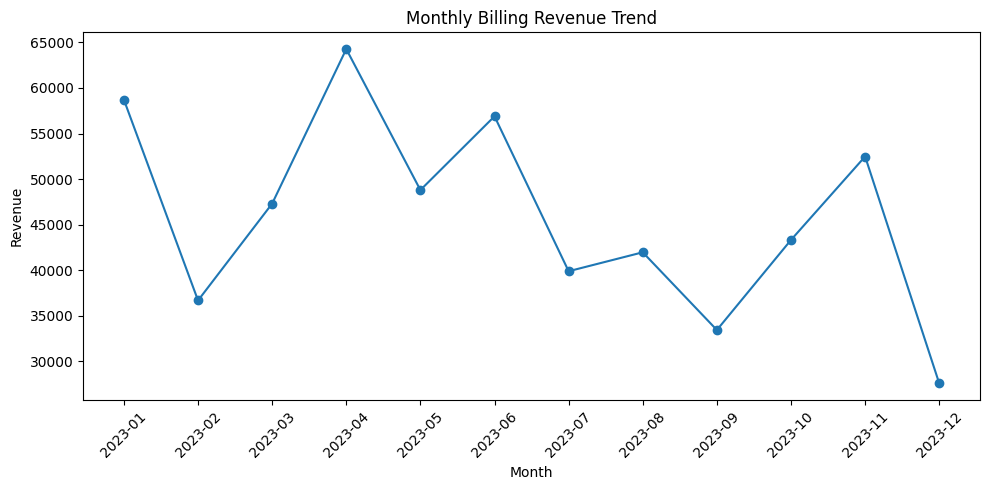

In [22]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["month"], monthly_revenue["total_revenue"], marker="o")
plt.title("Monthly Billing Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 17. Highest-Billed Patients

In [23]:
patient_revenue = (
    billing_df.groupby("patient_id")
    .agg(total_billed=("amount","sum"), billing_records=("bill_id","nunique"))
    .reset_index()
    .merge(patients_df[["patient_id","first_name","last_name"]],
           on="patient_id", how="left")
)

patient_revenue["patient_name"] = patient_revenue["first_name"] + " " + patient_revenue["last_name"]
patient_revenue["total_billed"] = patient_revenue["total_billed"].round(2)

patient_revenue[
    ["patient_id","patient_name","total_billed","billing_records"]
].sort_values("total_billed", ascending=False).head(10)


,patient_id,patient_name,total_billed,billing_records
10,P012,Laura Davis,"30,053.08",10
46,P049,David Moore,"23,554.06",7
13,P016,Michael Taylor,"22,967.94",7
33,P036,Michael Wilson,"21,583.56",7
22,P025,Robert Wilson,"19,513.17",5
4,P005,David Wilson,"18,609.91",8
32,P035,David Wilson,"18,407.42",7
45,P048,Emily Miller,"17,082.48",5
8,P010,Michael Taylor,"15,929.15",6
14,P017,Jane Jones,"14,850.28",4


## 18. Business Questions Answered

- What is the hospital's overall patient, doctor, appointment, treatment, and billing volume?
- What percentage of appointments are no-shows, completed, or cancelled?
- Which specializations have the highest appointment demand?
- Which specializations have the highest no-show rates?
- Which doctors handle the highest appointment workload?
- Which treatment types have the highest activity and cost?
- Which specializations generate the highest billing revenue?
- Which specializations have the highest revenue per appointment?
- Which doctors combine high workload with high revenue?
- How does revenue change month over month?
- Which patients have the highest billed amounts?

All results are generated from the database rather than hard-coded into the notebook.


## 19. Business Recommendations

### Reduce no-shows
Use reminders, confirmations, and targeted follow-up for doctors or specializations with unusually high no-show rates.

### Improve capacity planning
Monitor high-demand specializations and high-workload doctors to identify scheduling or staffing pressure.

### Track revenue efficiency
Use revenue per appointment alongside appointment volume and total revenue instead of relying on a single KPI.

### Monitor monthly trends
Use appointment and revenue trends for staffing and resource planning.

### Maintain data quality
Continue validating missing values, invalid financial values, and relationships across the five tables.


## 20. Final Takeaway

**Relational Data → Data Quality → SQL/Python Analysis → KPIs → Insights → Recommendations**

This project demonstrates practical skills in MySQL, SQL, Python, Pandas, relational data modeling, KPI development, operational analysis, revenue analysis, and business-oriented storytelling.
